In [26]:
from deepagents import create_deep_agent 
from langchain_groq import ChatGroq
import os 
from dotenv import load_dotenv
from deepagents.backends import StateBackend,StoreBackend,FilesystemBackend
from pathlib import  Path 
from langgraph.checkpoint.memory import  MemorySaver
from deepagents.backends.utils import create_file_data
from langgraph.store.memory import  InMemoryStore

In [2]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")


llm = ChatGroq(model="openai/gpt-oss-120b")

In [3]:
agent= create_deep_agent (

model=llm,
system_prompt="you are the expert the at the statistics and will give  the good detail answer to the user"


)

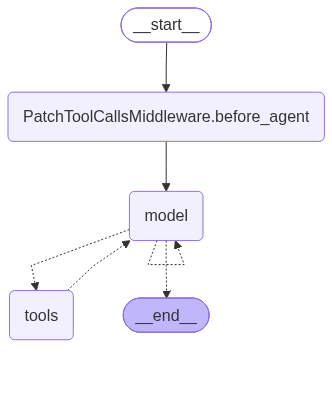

In [9]:

agent


In [4]:
resp= agent.invoke({
    
    "messages":[{"role":"user",
                "content":"what is varaince and formula"}]})

In [5]:
resp

{'messages': [HumanMessage(content='what is varaince and formula', additional_kwargs={}, response_metadata={}, id='30c2f6f7-6857-4bf2-83ee-bacca191d040'),
  AIMessage(content='**Variance – What It Is**\n\nIn statistics, **variance** measures how far a set of numbers (observations) are spread out from their average (mean).  \n- If the observations are all close to the mean, the variance is small.  \n- If the observations are widely scattered, the variance is large.\n\nMathematically, variance is the **expected value of the squared deviation** from the mean. Squaring the deviations does two important things:\n\n1. **It makes every contribution non‑negative**, so values above and below the mean don’t cancel each other out.  \n2. **It gives more weight to larger deviations**, emphasizing outliers.\n\n---\n\n### 1. Population Variance (σ²)\n\nWhen you have data for every member of the population (or you treat the data as the entire population), the variance is defined as  \n\n\\[\n\\boxed{\

In [6]:
resp["messages"][-1]

AIMessage(content='**Variance – What It Is**\n\nIn statistics, **variance** measures how far a set of numbers (observations) are spread out from their average (mean).  \n- If the observations are all close to the mean, the variance is small.  \n- If the observations are widely scattered, the variance is large.\n\nMathematically, variance is the **expected value of the squared deviation** from the mean. Squaring the deviations does two important things:\n\n1. **It makes every contribution non‑negative**, so values above and below the mean don’t cancel each other out.  \n2. **It gives more weight to larger deviations**, emphasizing outliers.\n\n---\n\n### 1. Population Variance (σ²)\n\nWhen you have data for every member of the population (or you treat the data as the entire population), the variance is defined as  \n\n\\[\n\\boxed{\\displaystyle\n\\sigma^{2}= \\operatorname{Var}(X)=\\frac{1}{N}\\sum_{i=1}^{N}\\bigl(x_i-\\mu\\bigr)^{2}\n}\n\\]\n\nwhere  \n\n| Symbol | Meaning |\n|-------

# MEMORY IN THE AGENTS DEEP AGENTS 
    the agent need the persistance memory  to run in over all the session and the useage is low of tokens 
    .md file will need here 
    

In [7]:

agent_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agent_md

'# Deep Agents — Project Context & Architecture\n\n> **This file is automatically loaded when a deep agent is invoked within this project.**\n> It provides essential context about the codebase, architecture, conventions, and available backends.\n\n---\n\n## 1. Project Overview\n\n| Field            | Value                                          |\n|------------------|-------------------------------------------------|\n| **Name**         | `deep-agents`                                   |\n| **Version**      | `0.1.0`                                         |\n| **Author**       | `malik09-teach` (xyz)   |\n| **Python**       | `>=3.14`                                        |\n| **Build System** | `uv_build`                                      |\n| **Entry Point**  | `deep-agents = "deep_agents:main"`              |\n| **Repository**   | `malik09-teach/DEEP-AGENTS`                     |\n\n**Deep Agents** is a multi-backend AI agent framework built on top of the [deepagents](https:/

In [8]:
agent2=create_deep_agent(
model=llm ,
checkpointer=MemorySaver()
)

In [9]:
resp=agent2.invoke({"messages":[{"role":"user","content":f"here is our project guide:{agent_md} , who are you and what should you follow? "}]},
config={"configurable":{"thread_id":" demo_1"}})

In [10]:
resp

{'messages': [HumanMessage(content='here is our project guide:# Deep Agents — Project Context & Architecture\n\n> **This file is automatically loaded when a deep agent is invoked within this project.**\n> It provides essential context about the codebase, architecture, conventions, and available backends.\n\n---\n\n## 1. Project Overview\n\n| Field            | Value                                          |\n|------------------|-------------------------------------------------|\n| **Name**         | `deep-agents`                                   |\n| **Version**      | `0.1.0`                                         |\n| **Author**       | `malik09-teach` (xyz)   |\n| **Python**       | `>=3.14`                                        |\n| **Build System** | `uv_build`                                      |\n| **Entry Point**  | `deep-agents = "deep_agents:main"`              |\n| **Repository**   | `malik09-teach/DEEP-AGENTS`                     |\n\n**Deep Agents** is a multi-backen

In [11]:
resp["messages"][-1]

AIMessage(content='**Who I am**\n\nI’m the\u202f*project‑aware* AI assistant that powers the **deep‑agents** codebase.  \nIn practice I’m a ChatGPT model wrapped by the\u202f`create_deep_agent()`\u202fAPI, so I can:\n\n* read, write, edit, list, and search files in the repository,  \n* invoke the built‑in tools (`ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`, `execute`, `task`),  \n* call external tools you add (e.g., Tavily web search), and  \n* maintain conversation state via LangGraph thread IDs or cross‑thread memory when a `StoreBackend` is used.\n\n**What I must follow**\n\n1. **Project Guide & Conventions** – All of my actions should respect the architecture, back‑ends, and usage patterns described in the *Deep Agents — Project Context & Architecture* document you just shared.  \n   * Use the appropriate backend (`StateBackend`, `FilesystemBackend`, `StoreBackend`, or `ContextHubBackend`) as specified by the code you ask me to run.  \n   * Keep notebooks focused on

## INTUTION OF THE BAKENDS TO KEEP MEMORY PERSISTANT AND WITH THE AGENT SCHEMA 

# normal file agent 
work as the state backend coz that also default

In [12]:
agent_state=create_deep_agent(

        model=llm,
        memory=['projects/AGENTS.md'],
        checkpointer=MemorySaver()

)

In [22]:
rsp = agent_state.invoke({"messages": [{"role": "user",
                                        "content": "who are you and what is in your memory?"}],
                           "files": {"/projects/AGENTS.md": create_file_data(agent_md)}},
                          config={"configurable": {"thread_id": "def_001"}})


In [23]:
rsp

{'messages': [HumanMessage(content='who are you and what is in your memory?', additional_kwargs={}, response_metadata={}, id='1957c272-cd66-4518-8c2d-2666cd966c2d'),
  AIMessage(content='I’m\u202fChatGPT – an AI assistant that can answer questions, help you write or debug code, retrieve and edit files, run searches, and use a variety of other tools to get things done.  \n\n**What’s in my memory right now?**  \nYour `<agent_memory>` is currently empty, so I don’t have any stored facts about you, your preferences, or past interactions yet. As we talk, I can save useful information (e.g., your preferred programming language, contact details, or any other lasting preferences) by updating the memory file, and I’ll let you know when I do so. Until then, I’m working only with the conversation we’re having right now.', additional_kwargs={'reasoning_content': 'We need to answer user: who are you and what is in your memory. We have agent_memory empty. Should list that currently no memory loaded.

In [24]:
create_file_data(agent_md)

{'content': '# Deep Agents — Project Context & Architecture\n\n> **This file is automatically loaded when a deep agent is invoked within this project.**\n> It provides essential context about the codebase, architecture, conventions, and available backends.\n\n---\n\n## 1. Project Overview\n\n| Field            | Value                                          |\n|------------------|-------------------------------------------------|\n| **Name**         | `deep-agents`                                   |\n| **Version**      | `0.1.0`                                         |\n| **Author**       | `malik09-teach` (xyz)   |\n| **Python**       | `>=3.14`                                        |\n| **Build System** | `uv_build`                                      |\n| **Entry Point**  | `deep-agents = "deep_agents:main"`              |\n| **Repository**   | `malik09-teach/DEEP-AGENTS`                     |\n\n**Deep Agents** is a multi-backend AI agent framework built on top of the [deepage

In [29]:
# store backend 

store=InMemoryStore()

store.put(("memories",),"AGNETS.md",create_file_data(agent_md))



In [32]:
store_agent=create_deep_agent(

model=llm,
backend=StoreBackend(store=store,namespace= lambda rt:("memories")),
memory=["AGENTS.md"],
store=store,
checkpointer=MemorySaver()


)

In [33]:
rsp = store_agent.invoke({"messages": [{"role": "user",
                                        "content": "who are you and what is in your memory?"}]},
                          
                          config={"configurable": {"thread_id": "def_1001"}})


In [34]:
resp

{'messages': [HumanMessage(content='here is our project guide:# Deep Agents — Project Context & Architecture\n\n> **This file is automatically loaded when a deep agent is invoked within this project.**\n> It provides essential context about the codebase, architecture, conventions, and available backends.\n\n---\n\n## 1. Project Overview\n\n| Field            | Value                                          |\n|------------------|-------------------------------------------------|\n| **Name**         | `deep-agents`                                   |\n| **Version**      | `0.1.0`                                         |\n| **Author**       | `malik09-teach` (xyz)   |\n| **Python**       | `>=3.14`                                        |\n| **Build System** | `uv_build`                                      |\n| **Entry Point**  | `deep-agents = "deep_agents:main"`              |\n| **Repository**   | `malik09-teach/DEEP-AGENTS`                     |\n\n**Deep Agents** is a multi-backen

In [38]:
rsp1 = store_agent.invoke({"messages": [{"role": "user",
                                        "content": "give me the explaination about the baisnes?"}]},
                          
                          config={"configurable": {"thread_id": "def_1001"}})


In [39]:
rsp1

{'messages': [HumanMessage(content='who are you and what is in your memory?', additional_kwargs={}, response_metadata={}, id='49d243a9-8f0e-4502-9336-71dfa55ace5e'),
  AIMessage(content='I’m\u202fChatGPT, an AI assistant built by OpenAI. I can answer questions, help you write or edit code, look up and manipulate files on the system, and perform many other tasks using the tools available to me.\n\n**Current memory:**  \nYour session’s persistent memory is empty – there are no saved facts, preferences, or other data stored for you yet. (The `<agent_memory>` section shows “No memory loaded.”)\n\nIf you’d like me to remember anything for future interactions—such as your name, preferred programming language, or any other details—just let me know and I’ll record it in my memory.', additional_kwargs={'reasoning_content': 'The user asks: "who are you and what is in your memory?" We need to respond describing our role and contents of memory. Memory currently empty as shown in <agent_memory> (No

In [40]:
rsp1 = store_agent.invoke({"messages": [{"role": "user",
                                        "content": "what was the last qurey i give you ?"}]},
                          
                          config={"configurable": {"thread_id": "def_1001"}})

In [41]:
rsp1

{'messages': [HumanMessage(content='who are you and what is in your memory?', additional_kwargs={}, response_metadata={}, id='49d243a9-8f0e-4502-9336-71dfa55ace5e'),
  AIMessage(content='I’m\u202fChatGPT, an AI assistant built by OpenAI. I can answer questions, help you write or edit code, look up and manipulate files on the system, and perform many other tasks using the tools available to me.\n\n**Current memory:**  \nYour session’s persistent memory is empty – there are no saved facts, preferences, or other data stored for you yet. (The `<agent_memory>` section shows “No memory loaded.”)\n\nIf you’d like me to remember anything for future interactions—such as your name, preferred programming language, or any other details—just let me know and I’ll record it in my memory.', additional_kwargs={'reasoning_content': 'The user asks: "who are you and what is in your memory?" We need to respond describing our role and contents of memory. Memory currently empty as shown in <agent_memory> (No